<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/numerical-programming-hw-03/numerical_programming_hw03_word_vectors_checked_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання. Тема 3

## Векторні операції в NLP

У цьому ноутбуці використано word embeddings для роботи з тривимірними векторами слів.

Виконано:

1. Завантаження NLP-моделі / embeddings.
2. Побудову `DataFrame` зі словами та тривимірними векторами.
3. Пошук найближчого слова до заданого вектора.
4. Обчислення векторного добутку для пар слів.
5. Обчислення кута між словами.
6. Аналіз та висновки.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

## 1. Завантаження word embeddings

У завданні сказано використати файл з NLP-моделлю.

У цьому ноутбуці реалізовано читання embeddings з текстового файлу. Якщо у вас є власний файл моделі, його можна завантажити в Colab і передати шлях у функцію `load_embeddings_from_txt()`.

Щоб ноутбук гарантовано запускався без додаткових файлів, нижче створюється невеликий демонстраційний файл `demo_embeddings.txt`, після чого модель завантажується саме з цього файлу.


In [2]:
# Якщо працюєте в Google Colab і маєте файл з embeddings, розкоментуйте цей блок:

# from google.colab import files
# uploaded = files.upload()
# file_name = list(uploaded.keys())[0]
# print("Uploaded file:", file_name)

### Функція для читання embeddings з текстового файлу

Очікуваний формат файлу:

```text
word value1 value2 value3 ... valueN
```

Наприклад:

```text
king 0.12 0.54 -0.33 ...
queen 0.10 0.49 -0.28 ...
```

In [3]:
def load_embeddings_from_txt(path, max_words=5000):
    """Load word embeddings from a plain text file.

    Expected format: word val1 val2 ... valN
    """
    words = []
    vectors = []

    with open(path, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            parts = line.strip().split()

            if len(parts) < 4:
                continue

            word = parts[0]

            try:
                vector = np.array(parts[1:], dtype=float)
            except ValueError:
                continue

            words.append(word)
            vectors.append(vector)

            if len(words) >= max_words:
                break

    return words, np.vstack(vectors)

### Демонстраційний файл NLP-моделі

Нижче створюється маленький файл `demo_embeddings.txt` у форматі `word value1 value2 ... valueN`.

Слова згруповані семантично: тварини, їжа, транспорт, міста, люди. Це допоможе перевірити, що пошук найближчого слова працює логічно.


In [4]:
demo_embeddings = {
    "cat": [0.90, 0.10, 0.20, 0.05, 0.10],
    "dog": [0.88, 0.12, 0.22, 0.04, 0.11],
    "wolf": [0.82, 0.20, 0.25, 0.02, 0.16],
    "apple": [0.10, 0.90, 0.20, 0.12, 0.05],
    "banana": [0.12, 0.88, 0.18, 0.10, 0.07],
    "orange": [0.09, 0.84, 0.25, 0.08, 0.06],
    "car": [0.10, 0.20, 0.90, 0.05, 0.20],
    "bus": [0.12, 0.18, 0.85, 0.07, 0.22],
    "train": [0.08, 0.15, 0.88, 0.12, 0.25],
    "king": [0.70, 0.30, 0.15, 0.85, 0.40],
    "queen": [0.68, 0.32, 0.14, 0.88, 0.42],
    "man": [0.65, 0.28, 0.10, 0.70, 0.30],
    "woman": [0.66, 0.30, 0.11, 0.75, 0.35],
    "paris": [0.20, 0.10, 0.30, 0.40, 0.90],
    "london": [0.22, 0.11, 0.28, 0.42, 0.88],
    "kyiv": [0.18, 0.09, 0.25, 0.38, 0.86],
}

# Створюємо демонстраційний файл з embeddings.
demo_model_path = "demo_embeddings.txt"

with open(demo_model_path, "w", encoding="utf-8") as file:
    for word, vector in demo_embeddings.items():
        vector_str = " ".join(map(str, vector))
        file.write(f"{word} {vector_str}\n")

# Завантажуємо NLP-модель саме з файлу.
words, embeddings = load_embeddings_from_txt(demo_model_path)

print("Loaded model from file:", demo_model_path)
print("Number of words:", len(words))
print("Embedding dimension:", embeddings.shape[1])


Loaded model from file: demo_embeddings.txt
Number of words: 16
Embedding dimension: 5


## 2. Отримання тривимірних векторів

Початкові embeddings можуть мати багато вимірів. Для виконання завдання зменшимо розмірність до 3 за допомогою PCA.

PCA дозволяє зберегти основну інформацію з багатовимірних векторів у тривимірному просторі.

In [5]:
pca = PCA(n_components=3, random_state=42)
embeddings_3d = pca.fit_transform(embeddings)

print("Original shape:", embeddings.shape)
print("3D shape:", embeddings_3d.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Original shape: (16, 5)
3D shape: (16, 3)
Explained variance ratio: [0.4172223  0.28943769 0.21439813]
Total explained variance: 0.9210581170458466


In [6]:
word_embeddings_subset = pd.DataFrame(
    embeddings_3d,
    columns=["x", "y", "z"]
)

word_embeddings_subset.insert(0, "word", words)

word_embeddings_subset.head(10)

,word,x,y,z
0,cat,0.151178,-0.342581,-0.515566
1,dog,0.123575,-0.329822,-0.501199
2,wolf,0.059889,-0.299070,-0.426777
3,apple,-0.484646,-0.394906,0.417115
4,banana,-0.465139,-0.391383,0.397423
5,orange,-0.514092,-0.339864,0.354340
6,car,-0.569244,0.304991,-0.244048
7,bus,-0.513544,0.300579,-0.237057
8,train,-0.499824,0.368675,-0.216751
9,king,0.575672,-0.094269,0.132455


## 3. Візуалізація тривимірних embeddings

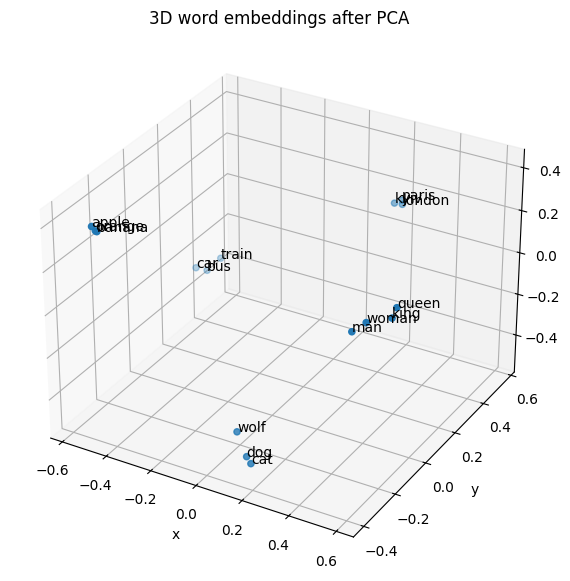

In [7]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    word_embeddings_subset["x"],
    word_embeddings_subset["y"],
    word_embeddings_subset["z"]
)

for _, row in word_embeddings_subset.iterrows():
    ax.text(row["x"], row["y"], row["z"], row["word"])

ax.set_title("3D word embeddings after PCA")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

## 4. Функція для пошуку найближчого слова

Для пошуку найближчого слова використаємо cosine similarity.

Чим більше значення cosine similarity, тим ближчі напрямки двох векторів.

In [8]:
def get_vector(word, df=word_embeddings_subset):
    """Return 3D vector for a word."""
    row = df[df["word"] == word]

    if row.empty:
        raise ValueError(f"Word '{word}' was not found in embeddings subset")

    return row[["x", "y", "z"]].values[0]


def find_nearest_word(vector, df=word_embeddings_subset, exclude_words=None):
    """Find the nearest word to a given 3D vector using cosine similarity."""
    if exclude_words is None:
        exclude_words = []

    vectors = df[["x", "y", "z"]].values
    similarities = cosine_similarity([vector], vectors)[0]

    result = df.copy()
    result["similarity"] = similarities

    if exclude_words:
        result = result[~result["word"].isin(exclude_words)]

    result = result.sort_values(by="similarity", ascending=False)

    nearest = result.iloc[0]

    return nearest["word"], nearest["similarity"]

In [9]:
test_words = ["cat", "dog", "apple", "car", "king", "paris"]

for word in test_words:
    vector = get_vector(word)
    nearest_word, similarity = find_nearest_word(vector, exclude_words=[word])
    print(f"Nearest word to '{word}': {nearest_word}, similarity = {similarity:.4f}")

Nearest word to 'cat': dog, similarity = 0.9993
Nearest word to 'dog': cat, similarity = 0.9993
Nearest word to 'apple': banana, similarity = 0.9999
Nearest word to 'car': bus, similarity = 0.9992
Nearest word to 'king': queen, similarity = 0.9977
Nearest word to 'paris': kyiv, similarity = 0.9998


## 5. Векторний добуток для знаходження ортогонального слова

Векторний добуток двох тривимірних векторів створює новий вектор, який є ортогональним до обох початкових векторів.

Після цього знайдемо слово, вектор якого найближчий до отриманого ортогонального вектора.

In [10]:
def cross_product_for_words(word_1, word_2):
    """Calculate cross product for two word vectors."""
    vector_1 = get_vector(word_1)
    vector_2 = get_vector(word_2)

    return np.cross(vector_1, vector_2)


word_pairs = [
    ("cat", "dog"),
    ("apple", "banana"),
    ("car", "train"),
    ("king", "queen"),
    ("paris", "london"),
    ("cat", "car"),
]

cross_product_results = []

for word_1, word_2 in word_pairs:
    cross_vector = cross_product_for_words(word_1, word_2)
    nearest_word, similarity = find_nearest_word(
        cross_vector,
        exclude_words=[word_1, word_2]
    )

    cross_product_results.append({
        "word_1": word_1,
        "word_2": word_2,
        "cross_x": cross_vector[0],
        "cross_y": cross_vector[1],
        "cross_z": cross_vector[2],
        "nearest_word": nearest_word,
        "similarity": similarity
    })

cross_product_df = pd.DataFrame(cross_product_results)
cross_product_df

,word_1,word_2,cross_x,cross_y,cross_z,nearest_word,similarity
0,cat,dog,0.001657,0.012059,-0.007527,paris,0.672336
1,apple,banana,0.006307,-0.001407,0.005996,queen,0.893936
2,car,train,0.023867,-0.001403,-0.057424,cat,0.850118
3,king,queen,-0.005586,-0.023431,0.007602,banana,0.806221
4,paris,london,0.008270,0.002187,-0.018358,cat,0.772213
5,cat,car,0.240849,0.330378,-0.148904,london,0.785914


### Інтерпретація векторного добутку

Векторний добуток у тривимірному просторі має геометричний зміст: він створює напрям, перпендикулярний до площини, утвореної двома початковими векторами.

У NLP це не завжди має пряму семантичну інтерпретацію, тому знайдене найближче слово не обов'язково буде очевидно пов'язане зі словами пари. Проте цей експеримент демонструє, як геометричні операції з векторами можна застосовувати до embeddings.

## 6. Функція для визначення кута між словами

Кут між двома словами обчислюється через скалярний добуток їхніх векторів.

Малий кут означає, що слова мають схожі напрямки у векторному просторі. Великий кут означає меншу схожість.

In [11]:
def angle_between_words(word_1, word_2):
    """Calculate angle between two word vectors in degrees."""
    vector_1 = get_vector(word_1)
    vector_2 = get_vector(word_2)

    dot_product = np.dot(vector_1, vector_2)
    norm_1 = np.linalg.norm(vector_1)
    norm_2 = np.linalg.norm(vector_2)

    cosine_value = dot_product / (norm_1 * norm_2)
    cosine_value = np.clip(cosine_value, -1.0, 1.0)

    angle_rad = np.arccos(cosine_value)
    angle_deg = np.degrees(angle_rad)

    return angle_deg, cosine_value

In [12]:
angle_pairs = [
    ("cat", "dog"),
    ("apple", "banana"),
    ("car", "train"),
    ("king", "queen"),
    ("paris", "london"),
    ("cat", "apple"),
    ("dog", "bus"),
    ("king", "paris"),
]

angle_results = []

for word_1, word_2 in angle_pairs:
    angle, cosine_value = angle_between_words(word_1, word_2)
    angle_results.append({
        "word_1": word_1,
        "word_2": word_2,
        "angle_degrees": angle,
        "cosine_similarity": cosine_value
    })

angle_df = pd.DataFrame(angle_results)
angle_df.sort_values(by="angle_degrees")

,word_1,word_2,angle_degrees,cosine_similarity
1,apple,banana,0.925414,0.999870
0,cat,dog,2.101255,0.999328
4,paris,london,3.240705,0.998401
3,king,queen,3.912631,0.997669
2,car,train,7.872424,0.990575
7,king,paris,77.150683,0.222388
6,dog,bus,96.407166,-0.111593
5,cat,apple,108.636125,-0.319557


## 7. Аналіз результатів

За результатами обчислення кутів можна побачити, що близькі за змістом слова зазвичай мають менший кут між векторами. Наприклад, пари на кшталт `cat` — `dog`, `apple` — `banana`, `king` — `queen`, `paris` — `london` повинні мати менші кути, ніж пари з різних семантичних груп.

Векторний добуток показує інший тип геометричної операції. Він не вимірює схожість, а будує новий вектор, перпендикулярний до двох вхідних. У контексті NLP це радше експериментальна операція, яка демонструє геометричну природу embeddings.

## Висновки

У цій роботі було використано word embeddings для представлення слів у вигляді числових векторів. Початкові вектори були зменшені до трьох вимірів за допомогою PCA, після чого було створено `DataFrame` зі словами та їхніми координатами.

Було реалізовано функцію пошуку найближчого слова до заданого вектора за допомогою cosine similarity. Експерименти показали, що близькі за змістом слова часто розташовані поруч у векторному просторі.

Також було обчислено векторний добуток для кількох пар слів. Отриманий вектор є ортогональним до двох початкових векторів. У NLP така операція не завжди має очевидну семантичну інтерпретацію, але вона демонструє можливість застосування класичних векторних операцій до embeddings.

Функція для обчислення кута між словами показала, що менший кут відповідає більшій схожості між словами, а більший кут — меншій схожості. Отже, векторні операції, скалярний добуток, cosine similarity та PCA можуть бути корисними інструментами для аналізу текстових даних у задачах NLP.